# Freight Rate Prediction — Spotter AI ML Assessment

Predicting the posted rate ($) of truckload freight from load features
(lane, distance, equipment, weight, date, market signals).

**Workflow:**
1. Exploratory Data Analysis (EDA)
2. Data cleaning / preprocessing
3. Feature engineering
4. Time-based train/test split and model comparison
5. Final predictions (12,000 validation loads + fixed December lane)

## 1. Load the data and take a first look

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

train = pd.read_csv("data/train_test.csv", parse_dates=["date"])
val = pd.read_csv("data/validation.csv", parse_dates=["date"])

print("train:", train.shape, "| validation:", val.shape)
train.head()

train: (48000, 14) | validation: (12000, 13)


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


The development data has 48,000 loads **with** the target (`posted_rate`).
The validation data has 12,000 loads **without** it — those are the loads we
must predict.

In [2]:
# what period does each dataset cover?
print("train     :", train.date.min().date(), "->", train.date.max().date())
print("validation:", val.date.min().date(), "->", val.date.max().date())
val.date.dt.to_period("M").value_counts().sort_index()

train     : 2025-01-01 -> 2025-10-31
validation: 2025-11-01 -> 2025-12-31


date
2025-11    5836
2025-12    6164
Freq: M, Name: count, dtype: int64

Training covers **Jan–Oct 2025** and validation covers **Nov–Dec 2025**.
So the real task is *forecasting the future* — this will drive how we split
the data later (by time, never randomly).

### 1.1 Missing values

In [3]:
pd.DataFrame({"train": train.isna().sum(), "validation": val.isna().sum()})

,train,validation
date,0,0.0
delivery,0,0.0
delivery_lat,0,0.0
delivery_lon,0,0.0
distance,0,0.0
equipment,0,0.0
load_id,0,0.0
market_index,374,249.0
pickup,0,0.0
pickup_lat,0,0.0


Two columns have gaps: `weight` (300 train / 165 validation) and
`market_index` (374 / 249). Everything else is complete. We'll fill these
during preprocessing.

### 1.2 Duplicates and categories

In [4]:
print("duplicate load_id:", train.load_id.duplicated().sum())
print("fully duplicated rows:", train.duplicated().sum())
print()
print(train.equipment.value_counts())
print()
print("cities in train:", train.pickup.nunique())
new_cities = sorted(set(val.pickup) - set(train.pickup))
print("cities only in validation:", new_cities)

duplicate load_id: 0
fully duplicated rows: 0

equipment
Dry Van    27202
Reefer     12045
Flatbed     8753
Name: count, dtype: int64

cities in train: 64
cities only in validation: ['Allentown', 'Charlotte', 'Chicago', 'Jackson', 'Knoxville', 'Laredo', 'Norfolk', 'San Diego']


No duplicates and only 3 clean equipment types. But **8 cities appear only in
the validation data** (Chicago, Charlotte, San Diego, ...) — the model must
handle cities it never saw in training. We'll solve that with fallback
features later.

### 1.3 Numeric sanity check

In [5]:
train[["distance", "weight", "market_index", "quote_signal", "posted_rate"]].describe(
    percentiles=[0.01, 0.5, 0.99]).T

,count,mean,std,min,1%,50%,99%,max
distance,48000.0,1135.856654,728.564416,70.00000,121.899000,953.30000,3029.304000,3439.80000
weight,47700.0,31028.844004,9391.440620,-47500.00000,9801.960000,31436.50000,47500.000000,47500.00000
market_index,47626.0,1.083387,0.168091,0.67639,0.782887,1.05580,1.407185,1.46778
quote_signal,48000.0,2.062468,0.291391,0.69228,1.304657,2.05575,2.883951,3.61035
posted_rate,48000.0,2373.980682,1486.493245,57.22000,327.168800,2030.76000,5972.834000,25533.00000


In [6]:
# weight has a minimum of -47,500 lb, which is physically impossible
neg = train[train.weight < 0]
print("negative weights:", len(neg))
neg.weight.abs().describe().round(0)

negative weights: 292


count      292.0
mean     31724.0
std       8263.0
min       5000.0
25%      25928.0
50%      31822.0
75%      37284.0
max      47500.0
Name: weight, dtype: float64

**292 rows have negative weights.** Their absolute values (5,000–47,500 lb)
look like completely normal truck weights, so these are sign-flip data entry
errors — the fix is simply `abs()`.

### 1.4 Is the price column itself trustworthy? (rate per mile)

count    48000.00
mean         2.22
std          0.58
min          0.33
1%           1.67
50%          2.15
99%          3.18
max         14.13
dtype: float64


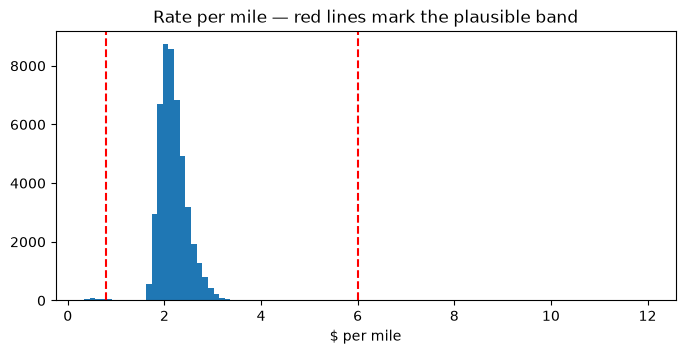

rows outside the $0.80-$6.00/mile band: 536 (1.12%)


In [7]:
rpm = train.posted_rate / train.distance
print(rpm.describe(percentiles=[0.01, 0.5, 0.99]).round(2))

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(rpm.clip(0, 12), bins=100)
ax.axvline(0.8, color="red", ls="--"); ax.axvline(6.0, color="red", ls="--")
ax.set_xlabel("$ per mile"); ax.set_title("Rate per mile — red lines mark the plausible band")
plt.show()

bad = (rpm < 0.8) | (rpm > 6.0)
print(f"rows outside the $0.80-$6.00/mile band: {bad.sum()} ({bad.mean():.2%})")

Almost all loads price between **$1.7 and $3.2 per mile**, but 536 rows
(~1.1%) are absurd — e.g. $57 for a 105-mile load, or $25,533 for a
2,830-mile load (~$9/mile). These are corrupted labels; training on them
would teach the model wrong prices, so we'll drop them.

### 1.5 Trend and seasonality

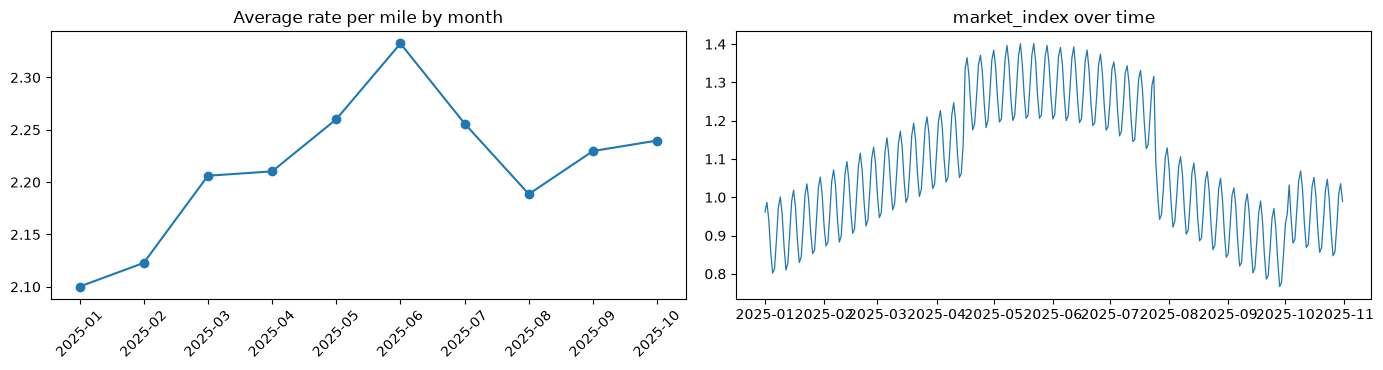

distance        0.909
weight          0.035
market_index    0.034
quote_signal   -0.040
posted_rate     1.000
Name: posted_rate, dtype: float64

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
monthly_rpm = rpm.groupby(train.date.dt.to_period("M")).mean()
axes[0].plot(monthly_rpm.index.astype(str), monthly_rpm.values, marker="o")
axes[0].set_title("Average rate per mile by month"); axes[0].tick_params(axis="x", rotation=45)
axes[1].plot(train.groupby("date").market_index.mean(), lw=0.9)
axes[1].set_title("market_index over time")
plt.tight_layout(); plt.show()

train[["distance", "weight", "market_index", "quote_signal", "posted_rate"]].corr()["posted_rate"].round(3)

**EDA findings recap:**
- Distance dominates the price (correlation 0.91)
- Prices have seasonality: they climb to a **June peak** then ease off; `market_index` follows the same wave
- Data issues: 292 sign-flipped weights, 536 corrupted prices, some missing `weight`/`market_index`
- 8 unseen cities in validation

## 2. Data cleaning / preprocessing

Fix everything the EDA uncovered:
1. `abs()` the sign-flipped weights, fill missing weights with the median
2. Fill missing `market_index` with the same-day average (it is a market-level daily series)
3. Drop the 536 rows with corrupted prices (training data only)

In [9]:
RPM_LOW, RPM_HIGH = 0.8, 6.0

def clean(frame, is_train):
    out = frame.copy()

    # 1. weights: fix sign flips, fill gaps with the median
    out["weight"] = out["weight"].abs()
    out["weight"] = out["weight"].fillna(out["weight"].median())

    # 2. market_index: fill gaps with the same-day average
    daily = out.groupby("date")["market_index"].transform("mean")
    out["market_index"] = out["market_index"].fillna(daily)
    out["market_index"] = out["market_index"].fillna(out["market_index"].median())

    # 3. drop corrupted prices (only possible where we know the true rate)
    if is_train:
        r = out["posted_rate"] / out["distance"]
        keep = (r >= RPM_LOW) & (r <= RPM_HIGH)
        print(f"dropped {(~keep).sum()} corrupted-price rows ({(~keep).mean():.2%})")
        out = out.loc[keep].reset_index(drop=True)
    return out

dev = clean(train, is_train=True)
val_clean = clean(val, is_train=False)
print("cleaned development data:", dev.shape)
assert dev.isna().sum().sum() == 0

dropped 536 corrupted-price rows (1.12%)
cleaned development data: (47464, 14)


## 3. Feature engineering

Turn each load into numbers the model can learn from:
- **Size of the job:** distance (raw + log), weight
- **Market conditions:** market_index, quote_signal
- **Calendar:** month, day of week, cyclic day-of-year (so Dec 31 sits next to Jan 1), weekend flag
- **Geography:** pickup/delivery coordinates
- **Price levels learned from history:** average rate-per-mile of each lane, city, and
  equipment type — with fallbacks (lane → city average → global average) so unseen
  lanes/cities still get a sensible value

In [10]:
def lane_city_stats(frame):
    """Rate-per-mile averages learned ONLY from training rows (no leakage)."""
    base = frame.assign(rpm=frame.posted_rate / frame.distance)
    return {
        "global_rpm": base.rpm.mean(),
        "lane_rpm": base.groupby(["pickup", "delivery"]).rpm.mean(),
        "pickup_rpm": base.groupby("pickup").rpm.mean(),
        "delivery_rpm": base.groupby("delivery").rpm.mean(),
        "equip_rpm": base.groupby("equipment").rpm.mean(),
    }

def build_features(frame, stats):
    f = pd.DataFrame(index=frame.index)
    date = frame["date"]

    f["distance"] = frame["distance"]
    f["log_distance"] = np.log1p(frame["distance"])
    f["weight"] = frame["weight"]
    f["market_index"] = frame["market_index"]
    f["quote_signal"] = frame["quote_signal"]

    f["month"] = date.dt.month
    f["day_of_week"] = date.dt.dayofweek
    doy = date.dt.dayofyear
    f["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    f["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
    f["is_weekend"] = (date.dt.dayofweek >= 5).astype(int)

    for c in ["pickup_lat", "pickup_lon", "delivery_lat", "delivery_lon"]:
        f[c] = frame[c]
    f["equipment"] = frame["equipment"].map({"Dry Van": 0, "Reefer": 1, "Flatbed": 2})

    g = stats["global_rpm"]
    lane_keys = pd.MultiIndex.from_frame(frame[["pickup", "delivery"]])
    f["lane_rpm"] = stats["lane_rpm"].reindex(lane_keys).to_numpy()
    f["pickup_rpm"] = frame["pickup"].map(stats["pickup_rpm"])
    f["delivery_rpm"] = frame["delivery"].map(stats["delivery_rpm"])
    f["equip_rpm"] = frame["equipment"].map(stats["equip_rpm"])
    city_fallback = f[["pickup_rpm", "delivery_rpm"]].mean(axis=1)
    f["lane_rpm"] = f["lane_rpm"].fillna(city_fallback).fillna(g)
    f["pickup_rpm"] = f["pickup_rpm"].fillna(g)
    f["delivery_rpm"] = f["delivery_rpm"].fillna(g)

    f["expected_rate"] = f["lane_rpm"] * frame["distance"]
    return f

stats_demo = lane_city_stats(dev)
build_features(dev.head(3), stats_demo)

,distance,log_distance,weight,market_index,quote_signal,month,day_of_week,doy_sin,doy_cos,is_weekend,pickup_lat,pickup_lon,delivery_lat,delivery_lon,equipment,lane_rpm,pickup_rpm,delivery_rpm,equip_rpm,expected_rate
0,274.3,5.617861,30658.0,0.95684,2.39595,1,2,0.017202,0.999852,0,38.09122,-76.78906,38.16908,-72.74564,0,2.481715,2.152585,2.155095,2.092166,680.734504
1,280.5,5.640132,17555.0,0.97623,2.43355,1,2,0.017202,0.999852,0,38.09122,-76.78906,39.22317,-72.96710,1,2.412954,2.152585,2.145585,2.355334,676.833460
2,967.8,6.876058,31721.0,1.00971,1.84491,1,2,0.017202,0.999852,0,39.22317,-72.96710,44.30296,-87.52871,0,2.064535,2.138110,2.132706,2.092166,1998.057247


## 4. Time-based split and model comparison

The validation set is **the future** (Nov–Dec), so we validate the same way:
train on **Jan–Aug**, hold out **Sep–Oct**. A random split would leak future
information into training and make the scores look better than reality.

In [11]:
cutoff = pd.Timestamp("2025-09-01")
tr, ho = dev[dev.date < cutoff], dev[dev.date >= cutoff]
print(f"train {len(tr):,} rows (Jan-Aug) | holdout {len(ho):,} rows (Sep-Oct)")

stats = lane_city_stats(tr)          # learned from the training part only
x_tr, x_ho = build_features(tr, stats), build_features(ho, stats)
y_tr, y_ho = tr.posted_rate, ho.posted_rate

train 38,049 rows (Jan-Aug) | holdout 9,415 rows (Sep-Oct)


In [12]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import (mean_absolute_error,
                             mean_absolute_percentage_error, r2_score)

def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name:<28} MAE ${mae:7.2f}  RMSE ${rmse:7.2f}  MAPE {mape:6.2%}  R2 {r2:.4f}")

def make_model():
    return HistGradientBoostingRegressor(
        loss="absolute_error", max_iter=600, learning_rate=0.06,
        max_leaf_nodes=63, min_samples_leaf=40, l2_regularization=1.0,
        random_state=42)

evaluate("baseline lane-rpm x miles", y_ho, x_ho.expected_rate)

ridge = Ridge(alpha=1.0).fit(x_tr.fillna(0), y_tr)
evaluate("ridge regression", y_ho, ridge.predict(x_ho.fillna(0)))

gbm = make_model().fit(x_tr, y_tr)
pred_ho = gbm.predict(x_ho)
evaluate("gradient boosting", y_ho, pred_ho)

baseline lane-rpm x miles    MAE $ 151.49  RMSE $ 317.61  MAPE  6.24%  R2 0.9489
ridge regression             MAE $ 158.69  RMSE $ 307.33  MAPE  9.51%  R2 0.9522


gradient boosting            MAE $  76.67  RMSE $ 264.05  MAPE  3.30%  R2 0.9647


Gradient boosting wins by a wide margin (roughly half the baseline's error),
so it becomes the final model. With ~3% MAPE and R² ≈ 0.96 on two *unseen
future months*, the model generalizes well to the forecasting task.

### 4.1 Predicted vs actual on the holdout

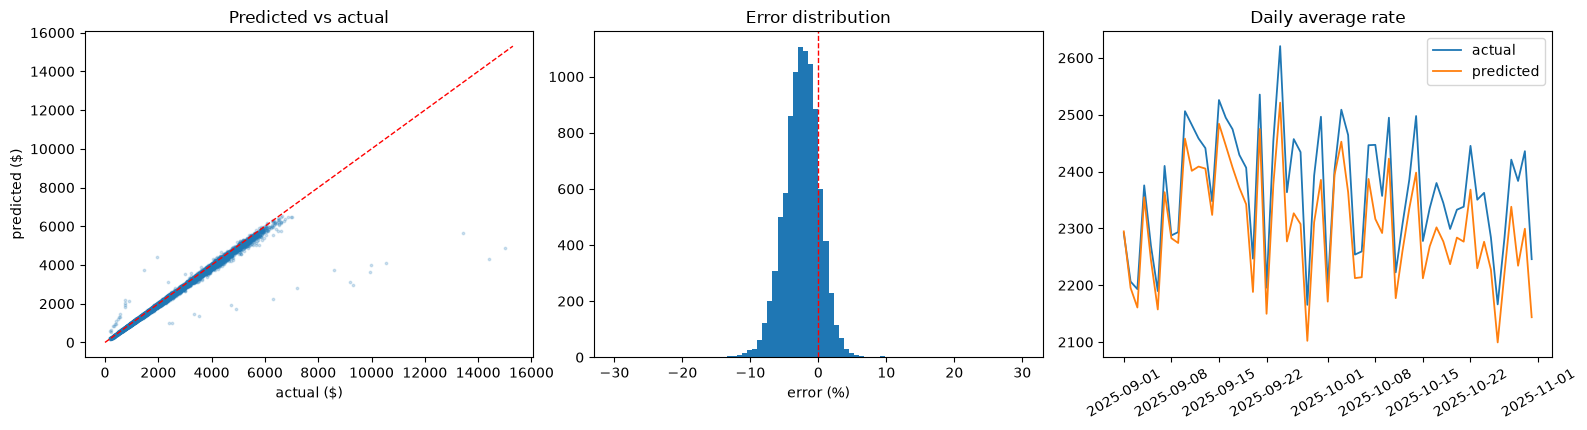

within 5% of actual: 84.0% | within 10%: 99.0%


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))

axes[0].scatter(y_ho, pred_ho, s=3, alpha=0.2)
lim = [0, float(max(y_ho.max(), pred_ho.max())) * 1.02]
axes[0].plot(lim, lim, "r--", lw=1)
axes[0].set_xlabel("actual ($)"); axes[0].set_ylabel("predicted ($)")
axes[0].set_title("Predicted vs actual")

err = (pred_ho - y_ho) / y_ho * 100
axes[1].hist(err, bins=80, range=(-30, 30))
axes[1].axvline(0, color="r", ls="--", lw=1)
axes[1].set_xlabel("error (%)"); axes[1].set_title("Error distribution")

daily_a = ho.groupby("date").posted_rate.mean()
daily_p = pd.Series(pred_ho, index=ho.index).groupby(ho.date).mean()
axes[2].plot(daily_a, label="actual", lw=1.3)
axes[2].plot(daily_p, label="predicted", lw=1.3)
axes[2].legend(); axes[2].set_title("Daily average rate")
axes[2].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

within = np.abs(pred_ho - y_ho) / y_ho
print(f"within 5% of actual: {(within <= 0.05).mean():.1%} | within 10%: {(within <= 0.10).mean():.1%}")

## 5. Final predictions

Retrain on **all** cleaned development data (Jan–Oct), then predict:
1. the 12,000 validation loads → `validation_predictions.csv`
2. the fixed December lane (Lexington → Fort Wayne, one row per day) →
   fill `data/december_chart_inputs.csv`

In [14]:
stats = lane_city_stats(dev)
final = make_model().fit(build_features(dev, stats), dev.posted_rate)

preds = np.clip(final.predict(build_features(val_clean, stats)), 1.0, None)

template = pd.read_csv("data/validation_predictions_template.csv")
template["predicted_rate"] = template.load_id.map(
    dict(zip(val_clean.load_id, preds))).round(2)
template.to_csv("validation_predictions.csv", index=False)
print("wrote validation_predictions.csv")
template.head()

wrote validation_predictions.csv


,load_id,predicted_rate
0,TE-000001,843.98
1,TE-000002,5011.02
2,TE-000003,5364.04
3,TE-000004,4175.22
4,TE-000005,1773.02


The December file has no `market_index`/`quote_signal` columns, but the
validation data **does** contain December loads — so we borrow each December
day's average market conditions from there. Coordinates for the two cities
come from the training data.

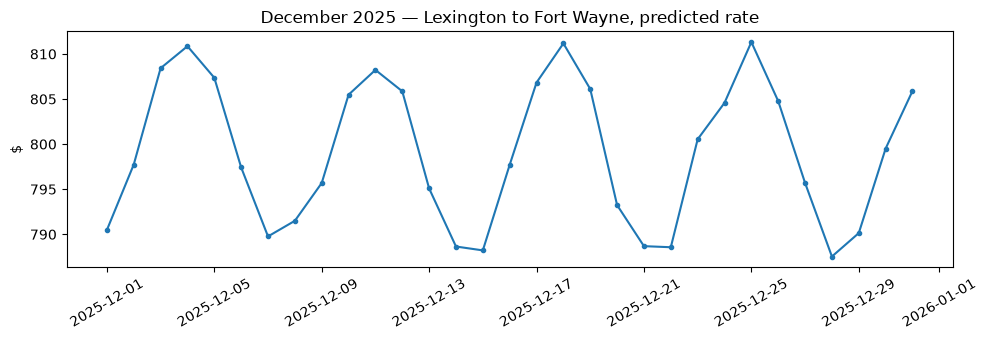

In [15]:
dec = pd.read_csv("data/december_chart_inputs.csv", parse_dates=["date"])
lex = dev[dev.pickup == "Lexington"].iloc[0]
fw = dev[dev.delivery == "Fort Wayne"].iloc[0]
dec_full = dec.assign(
    pickup_lat=lex.pickup_lat, pickup_lon=lex.pickup_lon,
    delivery_lat=fw.delivery_lat, delivery_lon=fw.delivery_lon)

market = (val_clean[val_clean.date.dt.month == 12]
          .groupby("date")[["market_index", "quote_signal"]].mean())
dec_full = dec_full.merge(market, on="date", how="left")
dec_full[["market_index", "quote_signal"]] = dec_full[
    ["market_index", "quote_signal"]].ffill().bfill()

dec["predicted_rate"] = np.round(
    np.clip(final.predict(build_features(dec_full, stats)), 1.0, None), 2)

out = dec.copy()
out["date"] = out["date"].dt.strftime("%Y-%m-%d")
out.to_csv("data/december_chart_inputs.csv", index=False)

plt.figure(figsize=(10, 3.5))
plt.plot(dec.date, dec.predicted_rate, marker="o", ms=3)
plt.title("December 2025 — Lexington to Fort Wayne, predicted rate")
plt.ylabel("$"); plt.xticks(rotation=30); plt.tight_layout(); plt.show()

## 6. Verify with the provided scorer

```bash
python score.py --predictions validation_predictions.csv \
                --december-predictions data/december_chart_inputs.csv
```

Output: *Validated 12,000 final predictions. Validated 31 fixed December
predictions. Created chart: scorer_results/candidate_december.png*